# 01: EDA of FD001

This notebook answers the questions that block modeling decisions. Every plot below feeds one of them, and the answers are collected in the Decisions cell at the end.

1. How should the RUL label be built? Depends on when degradation becomes visible: cap or no cap.
2. Which sensors carry degradation signal? Constant, noisy, or trending.
3. How are engine lifetimes distributed? Rules out clock-based prediction and shapes validation.
4. How to split train and validation without leakage? By engine, never by row.
5. What do the operational settings do in FD001? Expected: nothing, since there is one regime at sea level.

## 1. Load and sanity checks

Before exploring, check that the data matches its documentation: 100 engines, 26 columns, no missing values, and one contiguous cycle sequence per engine starting at 1. If any of these fail, nothing downstream can be trusted.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from turbofan_rul.config import SENSOR_COLS, SETTING_COLS
from turbofan_rul.data_loading import load_subset

df = load_subset("FD001", split="train")
df.shape

(20631, 26)

In [2]:
df.head()

,unit,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# Sanity checks: fail loudly here rather than mysteriously later.
assert df["unit"].nunique() == 100, "readme says 100 train engines"
assert df.isna().sum().sum() == 0, "no missing values expected"

# Each engine's cycles must be 1, 2, ..., n with no gaps:
# then its row count equals its max cycle, and cycles are strictly increasing.
per_unit = df.groupby("unit")["cycle"].agg(["min", "max", "count"])
assert (per_unit["min"] == 1).all(), "every engine starts at cycle 1"
assert (per_unit["max"] == per_unit["count"]).all(), "no gaps in cycle sequence"
assert df.groupby("unit")["cycle"].apply(lambda s: s.is_monotonic_increasing).all()

print("All sanity checks passed.")
per_unit["max"].describe().round(1)

All sanity checks passed.


count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: max, dtype: float64

## 2. Engine lifetimes and operational settings

Two quick questions from the framework. Q3: how spread out are lifetimes? If every engine lived about 200 cycles, RUL would be a clock problem and the sensors would be irrelevant. Q5: do the three settings vary at all in FD001? The readme says one condition (sea level), so they should be flat. Worth checking anyway.

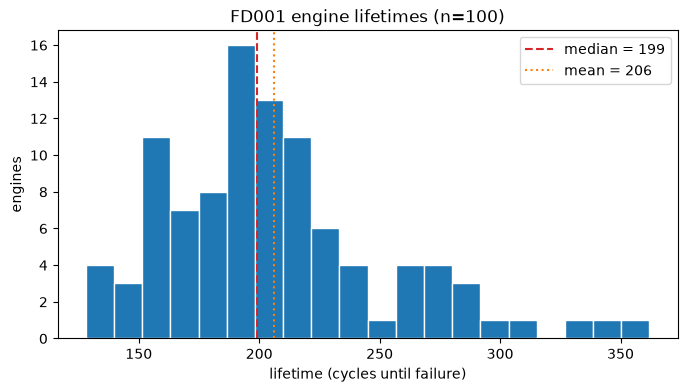

Range: 128-362 cycles  |  IQR: 177-229
Skewness: 1.03


In [4]:
lifetimes = df.groupby("unit")["cycle"].max().rename("lifetime")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lifetimes, bins=20, edgecolor="white")
ax.axvline(lifetimes.median(), color="C3", linestyle="--", label=f"median = {lifetimes.median():.0f}")
ax.axvline(lifetimes.mean(), color="C1", linestyle=":", label=f"mean = {lifetimes.mean():.0f}")
ax.set(xlabel="lifetime (cycles until failure)", ylabel="engines", title="FD001 engine lifetimes (n=100)")
ax.legend()
plt.show()

print(f"Range: {lifetimes.min()}-{lifetimes.max()} cycles  |  IQR: {lifetimes.quantile(.25):.0f}-{lifetimes.quantile(.75):.0f}")
print(f"Skewness: {lifetimes.skew():.2f}")

Right-skewed. Most engines fail between roughly 175 and 230 cycles, then there is a long tail of survivors up to 362. A predictor that only used the clock would be off by about 46 cycles on average and by more than 100 on the tail, so we need the sensors.

Now the settings, in two views: summary statistics, and the raw values against cycle for a few engines.

In [5]:
df[SETTING_COLS].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
setting_1,-0.000009,0.002187,-0.0087,0.0087
setting_2,0.000002,0.000293,-0.0006,0.0006
setting_3,100.000000,0.000000,100.0000,100.0000


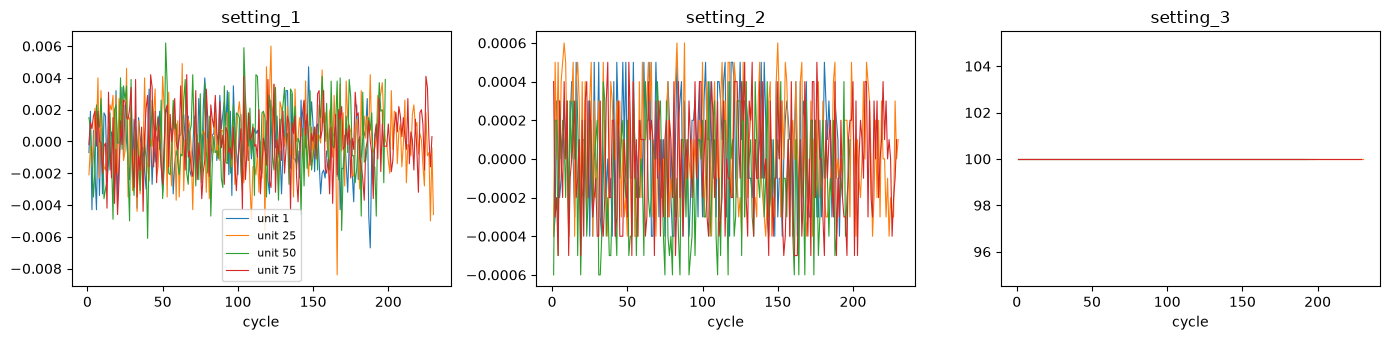

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, SETTING_COLS):
    for unit in [1, 25, 50, 75]:
        sub = df[df["unit"] == unit]
        ax.plot(sub["cycle"], sub[col], lw=0.8, label=f"unit {unit}")
    ax.set(title=col, xlabel="cycle")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

`setting_3` is exactly 100 everywhere. `setting_1` and `setting_2` are zero-mean noise with std around 0.002 and 0.0003: measurement jitter around one fixed operating point, with no structure over cycles and no difference between engines.

Conclusion for Q5: FD001 is a single operating regime. The settings carry no information and can be dropped from the feature set. They matter again in FD002 and FD004.

## 3. Which sensors carry degradation signal?

Three categories, screened from the cheapest check to the most expensive:

- A, constant: same value for every engine and cycle. A dispersion filter catches these.
- B, varies but says nothing: moves from cycle to cycle (noise) but shows no drift with age.
- C, trending: drifts consistently as the engine approaches failure. These are what the model will work with.

### 3a. Dispersion filter and visual screening

Sensors live on very different scales (sensor_9 is around 9000, sensor_16 around 0.03), so absolute `std` misleads. The coefficient of variation `std / |mean|` puts them on equal footing; the number of distinct values is a second check.

In [7]:
sensor_summary = pd.DataFrame({
    "mean": df[SENSOR_COLS].mean(),
    "std": df[SENSOR_COLS].std(),
    "nunique": df[SENSOR_COLS].nunique(),
})
sensor_summary["cv"] = sensor_summary["std"] / sensor_summary["mean"].abs()
sensor_summary.sort_values("cv").round(5)

,mean,std,nunique,cv
sensor_1,518.67000,0.00000,1,0.00000
sensor_19,100.00000,0.00000,1,0.00000
sensor_10,1.30000,0.00000,1,0.00000
sensor_18,2388.00000,0.00000,1,0.00000
sensor_16,0.03000,0.00000,1,0.00000
sensor_5,14.62000,0.00000,1,0.00000
sensor_8,2388.09665,0.07099,53,0.00003
sensor_13,2388.09615,0.07192,56,0.00003
sensor_6,21.60980,0.00139,2,0.00006
sensor_2,642.68093,0.50005,310,0.00078


In [8]:
# Do not test `std == 0`: floating-point arithmetic gives ~1e-15 for a constant column.
# "One distinct value" is the exact, scale-free definition of constant.
constant_sensors = sensor_summary.index[sensor_summary["nunique"] == 1].tolist()
near_constant = sensor_summary.index[sensor_summary["nunique"].between(2, 3)].tolist()
print("Category A (single value):     ", constant_sensors)
print("Suspect (2-3 distinct values):", near_constant)

Category A (single value):      ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Suspect (2-3 distinct values): ['sensor_6']


Six sensors are literally constant. `sensor_6` takes only two values and looks suspicious: a flat signal with a binary flicker is noise, not degradation. I keep it for the visual pass so the plot can settle it.

To compare engines with different lifetimes, plot each sensor against cycles to failure instead of cycle. Failure then lines up on the right for every engine, and if degradation only shows up near the end, every engine's curve should bend at the same place. Thin lines are raw values, thick lines a 20-cycle rolling mean (the readme warns about sensor noise).

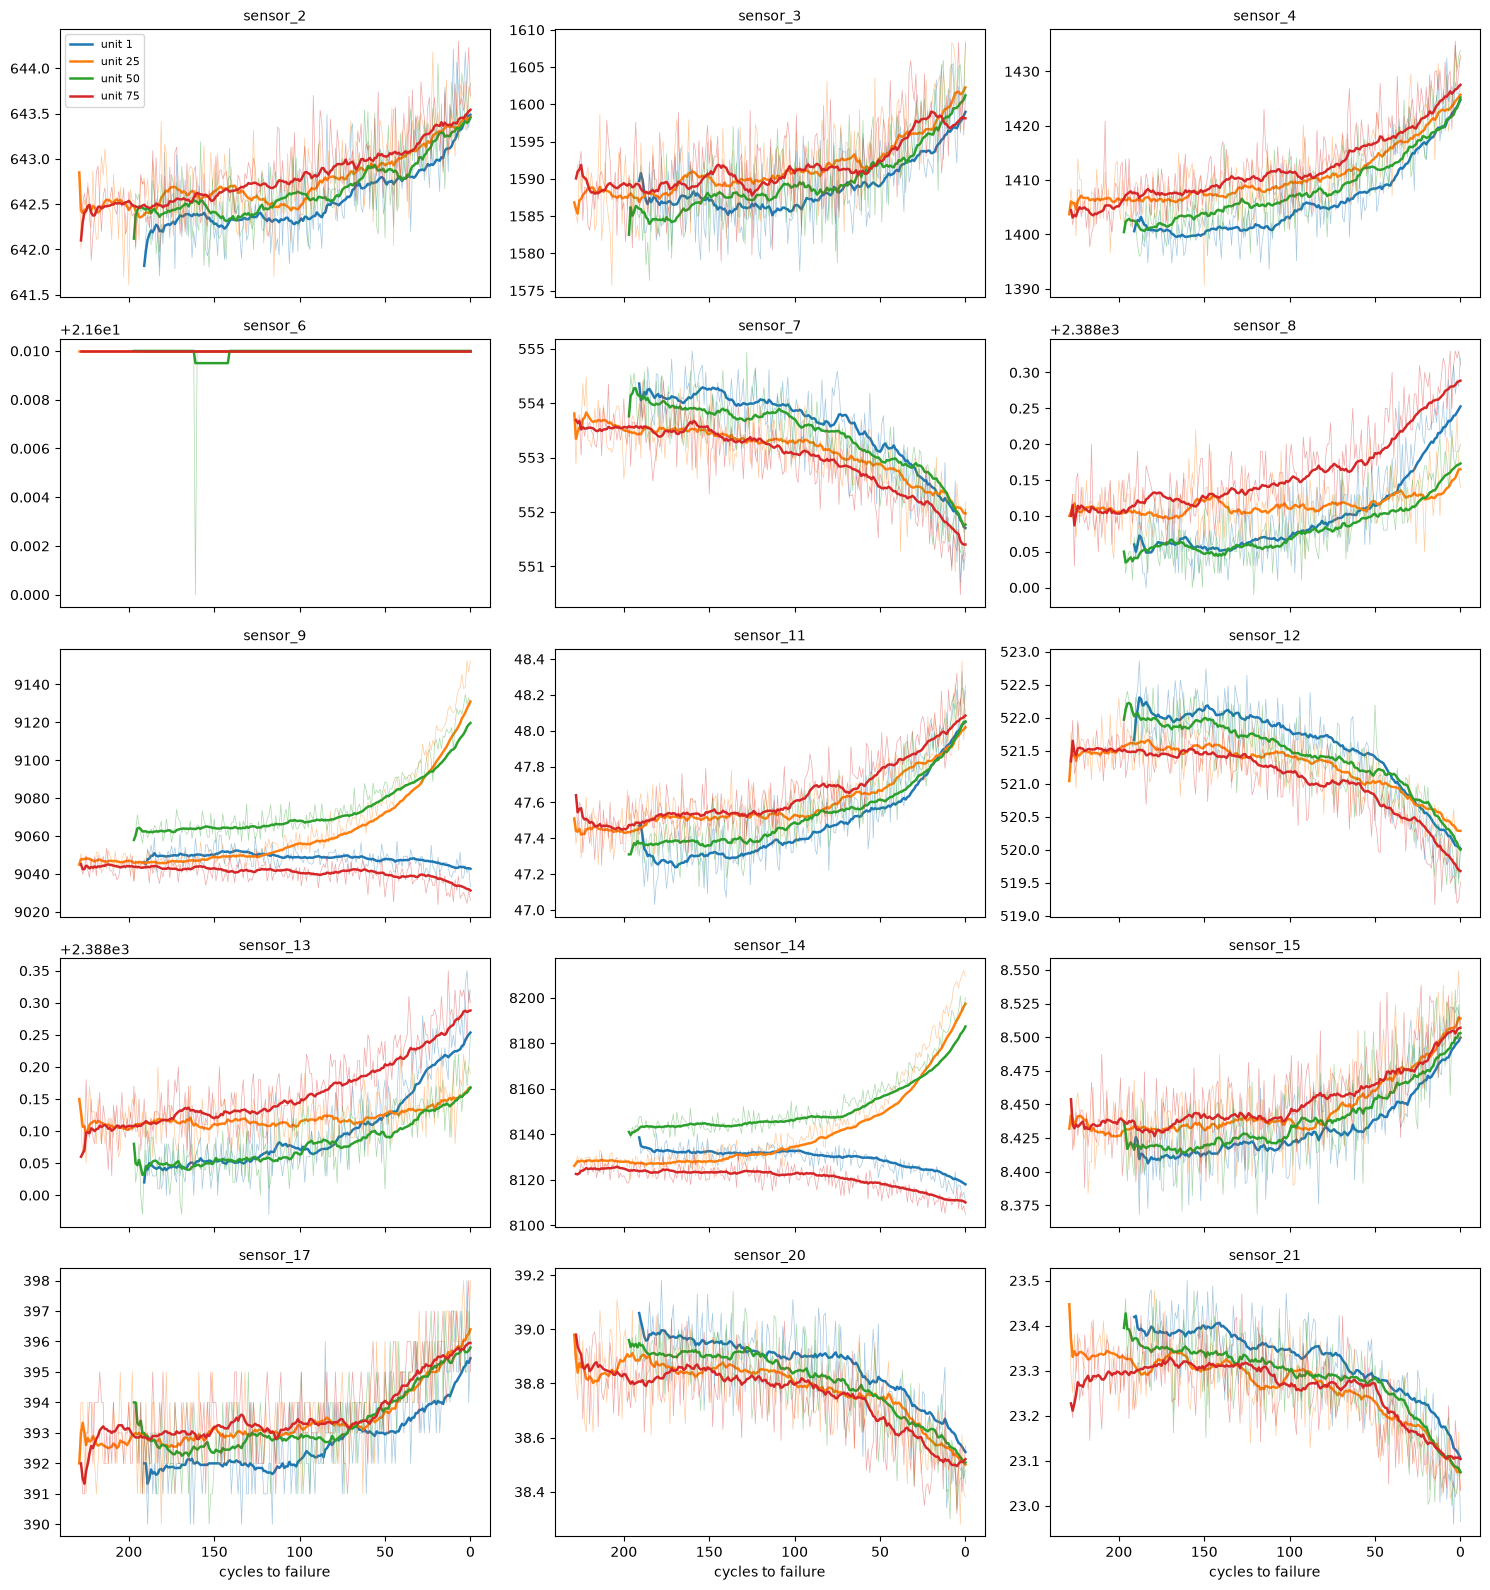

In [9]:
df["cycles_to_failure"] = df.groupby("unit")["cycle"].transform("max") - df["cycle"]

candidate_sensors = [s for s in SENSOR_COLS if s not in constant_sensors]
sample_units = [1, 25, 50, 75]

fig, axes = plt.subplots(5, 3, figsize=(15, 16), sharex=True)
for ax, col in zip(axes.flat, candidate_sensors):
    for i, unit in enumerate(sample_units):
        sub = df[df["unit"] == unit]
        ax.plot(sub["cycles_to_failure"], sub[col], lw=0.5, alpha=0.4, color=f"C{i}")
        ax.plot(sub["cycles_to_failure"], sub[col].rolling(20, min_periods=1).mean(),
                lw=1.8, color=f"C{i}", label=f"unit {unit}")
    ax.set_title(col, fontsize=10)
    ax.invert_xaxis()
axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("cycles to failure")
plt.tight_layout()
plt.show()

Visual classification, provisional until 3b confirms it with numbers:

| Category | Sensors | Evidence |
|----------|---------|----------|
| A, constant | 1, 5, 10, 16, 18, 19 | single distinct value |
| B, noise without drift | 6 | two values, binary flicker; flat otherwise |
| C, rising toward failure | 2, 3, 4, 8, 11, 13, 15, 17 | all four engines bend upward in the last 100 cycles or so |
| C, falling toward failure | 7, 12, 20, 21 | all four engines bend downward in the last 100 cycles or so |
| Ambiguous | 9, 14 | units 25 and 50 rise sharply; units 1 and 75 stay flat or fall. Direction is not consistent across engines |

Two more things the plot shows:

1. Degradation is only visible in the last 100 cycles or so. Every trending sensor is flat from the start of life until roughly 100 to 125 cycles before failure, then bends. This is the empirical basis for capping the RUL label (Q1): before the bend the sensors say nothing about remaining life, and a label that keeps counting down there asks the model for something it cannot know.
2. Engines have different baselines. Look at `sensor_7` or `sensor_12`: unit 1 sits visibly above unit 75 for its whole life. That offset is the "initial wear and manufacturing variation" from the readme. It is why rows from the same engine leak information into each other, and why a feature like "change since the engine's first cycles" may beat the raw value.

Sensors 9 and 14 are the reason 3b exists. Four engines are not enough to settle them.

### 3b. Quantifying trend across all 100 engines

For each sensor and each engine, compute the Spearman correlation between the smoothed sensor and engine age (`cycle`). Spearman because we care about monotonic drift rather than linearity, and the curves are clearly not linear. Then look at the distribution of the 100 correlations per sensor, not just its mean:

- `median_corr`: how strongly, and in which direction, the sensor drifts for a typical engine.
- `sign_consistency`: fraction of engines whose correlation has the same sign as the median. This is what separates a usable sensor from one that only works on some engines.

In [10]:
smoothed = df.groupby("unit")[candidate_sensors].transform(lambda s: s.rolling(20, min_periods=1).mean())
tmp = pd.concat([df[["unit", "cycle"]], smoothed], axis=1)

corr_by_unit = tmp.groupby("unit").apply(
    lambda g: g[candidate_sensors].corrwith(g["cycle"], method="spearman"),
    include_groups=False,
)  # rows = engines, columns = sensors

trend_summary = pd.DataFrame({
    "median_corr": corr_by_unit.median(),
    "sign_consistency": (np.sign(corr_by_unit) == np.sign(corr_by_unit.median())).mean(),
    "mean_abs_corr": corr_by_unit.abs().mean(),
}).sort_values("median_corr")
trend_summary.round(3)

/Users/alexmunozestornell/Documents/Personal_Projects/turbofan-rul/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,median_corr,sign_consistency,mean_abs_corr
sensor_12,-0.957,1.00,0.942
sensor_7,-0.952,1.00,0.926
sensor_21,-0.942,1.00,0.924
sensor_20,-0.941,1.00,0.924
sensor_6,0.472,0.61,0.474
sensor_3,0.906,1.00,0.888
sensor_17,0.912,1.00,0.896
sensor_2,0.918,1.00,0.902
sensor_14,0.926,0.62,0.846
sensor_9,0.931,0.72,0.848


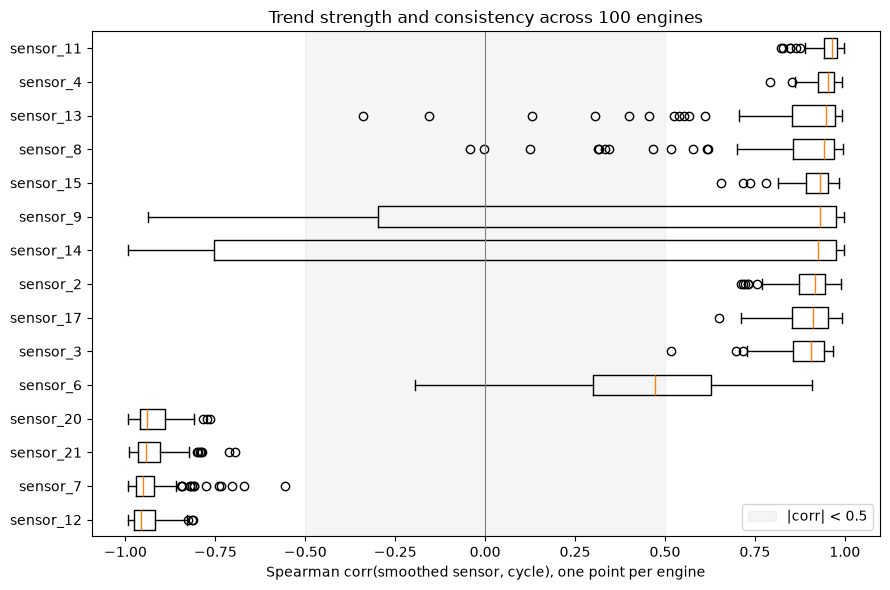

In [11]:
order = trend_summary.index
fig, ax = plt.subplots(figsize=(9, 6))
# dropna: sensor_6 is constant within many engines, where Spearman is undefined (NaN).
ax.boxplot([corr_by_unit[s].dropna() for s in order], orientation="horizontal", tick_labels=order, widths=0.6)
ax.axvline(0, color="grey", lw=0.8)
ax.axvspan(-0.5, 0.5, color="grey", alpha=0.08, label="|corr| < 0.5")
ax.set(xlabel="Spearman corr(smoothed sensor, cycle), one point per engine",
       title="Trend strength and consistency across 100 engines")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Read the table and the boxplot together, because they disagree.

The median correlation of sensors 9 and 14 is 0.93, as strong as the best sensors. Looking only at a mean or median, you would keep them without a second thought. But their boxes span from -0.75 to +0.97 and `sign_consistency` is 0.72 and 0.62: the distribution is bimodal. In roughly 70% of engines the sensor rises strongly with age; in the other 30% it falls just as strongly. The trend is real in every engine, but its direction depends on the engine. A model trained on raw `sensor_9` learns a rule that is wrong for a third of the fleet.

`sensor_6` shows no box at all. It is constant within most engines, so the correlation is undefined there (hence the `ConstantInputWarning` above). Where it is defined, consistency is 0.61, about a coin flip. Category B confirmed.

Sensors 8 and 13 have a handful of engines with weak correlation (the outliers near 0). They were the noisiest of the trending group in 3a (lowest coefficient of variation), so on short-lived engines 20 cycles of smoothing is not enough to reveal the drift. Consistency is 0.98, so they stay.

Does magnitude rescue 9 and 14? The hypothesis from 3a: the direction of the shaft-speed response depends on the engine's initial condition, but the distance from its own healthy baseline might still grow with age. To test it, take each engine's first 20 cycles as its baseline, compute `|smoothed - baseline|`, and repeat the correlation.

In [12]:
baseline = df.groupby("unit")[candidate_sensors].transform(lambda s: s.iloc[:20].mean())
abs_dev = (smoothed - baseline).abs()
tmp_dev = pd.concat([df[["unit", "cycle"]], abs_dev], axis=1)

corr_dev_by_unit = tmp_dev.groupby("unit").apply(
    lambda g: g[candidate_sensors].corrwith(g["cycle"], method="spearman"),
    include_groups=False,
)

trend_summary["median_corr_absdev"] = corr_dev_by_unit.median()
trend_summary["consistency_absdev"] = (np.sign(corr_dev_by_unit) == np.sign(corr_dev_by_unit.median())).mean()
trend_summary.loc[["sensor_9", "sensor_14", "sensor_2", "sensor_7"]].round(3)

/Users/alexmunozestornell/Documents/Personal_Projects/turbofan-rul/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,median_corr,sign_consistency,mean_abs_corr,median_corr_absdev,consistency_absdev
sensor_9,0.931,0.72,0.848,0.918,0.99
sensor_14,0.926,0.62,0.846,0.925,0.96
sensor_2,0.918,1.00,0.902,0.892,1.00
sensor_7,-0.952,1.00,0.926,0.928,1.00


It does. As absolute deviation from the engine's own baseline, sensors 9 and 14 reach 0.99 and 0.96 sign consistency with a median correlation around 0.92, indistinguishable from the clean sensors. The information was there all along; the raw value just carries it with a sign that changes from engine to engine.

Decision for Q2, sensor selection for FD001:

| Keep as raw value | Keep as deviation from own baseline | Drop |
|---|---|---|
| 2, 3, 4, 7, 8, 11, 12, 13, 15, 17, 20, 21 | 9, 14 | 1, 5, 6, 10, 16, 18, 19 |

Two caveats to carry forward:

- This selection is specific to FD001. FD003 adds fan degradation, which may wake up sensors that are dead here, and FD002/FD004 change regimes. Re-run this section per subset instead of hardcoding the list globally.
- The baseline trick for 9 and 14 is a preview of a more general idea: any sensor's deviation from its own early-life value removes the engine-specific offset seen in 3a. Whether that beats the raw value for the other 12 is a question for the feature engineering notebook, not for the EDA.

## 4. How should the RUL label be built?

The training files carry no label. The obvious construction is a linear countdown, `rul = lifetime - cycle`. But the readme says the engine "is operating normally at the start" and "develops a fault at some point", so for a long stretch the sensors contain nothing about remaining life while the linear label keeps changing. The alternative is piecewise linear: constant at some cap while the engine is healthy, then counting down.

The cap is not a free hyperparameter to tune on validation. It should reflect when degradation becomes detectable. Section 3 showed the bend at about 100 cycles on four engines; here we measure it on the whole fleet.

Health index: for the 12 raw trending sensors, take the smoothed deviation from each engine's own baseline, scale it by the sensor's fleet-wide std, flip the falling sensors so that "more degraded" is always positive, and average across sensors. That gives one number per row: how far this engine has drifted from its healthy self.

In [13]:
raw_keep = [f"sensor_{i}" for i in [2, 3, 4, 7, 8, 11, 12, 13, 15, 17, 20, 21]]
direction = np.sign(trend_summary.loc[raw_keep, "median_corr"])  # +1 rising, -1 falling

z = (smoothed[raw_keep] - baseline[raw_keep]) / df[raw_keep].std()
df["health_index"] = (z * direction).mean(axis=1)

# Fleet view: for each "cycles to failure", the distribution of the index across engines.
# Every engine lived >= 128 cycles, so up to ctf = 127 all 100 engines contribute.
fleet = (df.groupby("cycles_to_failure")["health_index"]
           .quantile([0.1, 0.5, 0.9]).unstack()
           .loc[:250])

# Healthy reference: the fleet median far from failure (150-250 cycles out).
healthy = fleet.loc[150:250, 0.5]
threshold = healthy.mean() + 3 * healthy.std()
onset = fleet.index[fleet[0.5] > threshold].max()  # farthest point where the median is clearly above healthy
print(f"Healthy median = {healthy.mean():.3f} ± {healthy.std():.3f}  ->  threshold = {threshold:.3f}")
print(f"Fleet median crosses the threshold at ~{onset} cycles before failure")

Healthy median = 0.030 ± 0.015  ->  threshold = 0.075
Fleet median crosses the threshold at ~142 cycles before failure


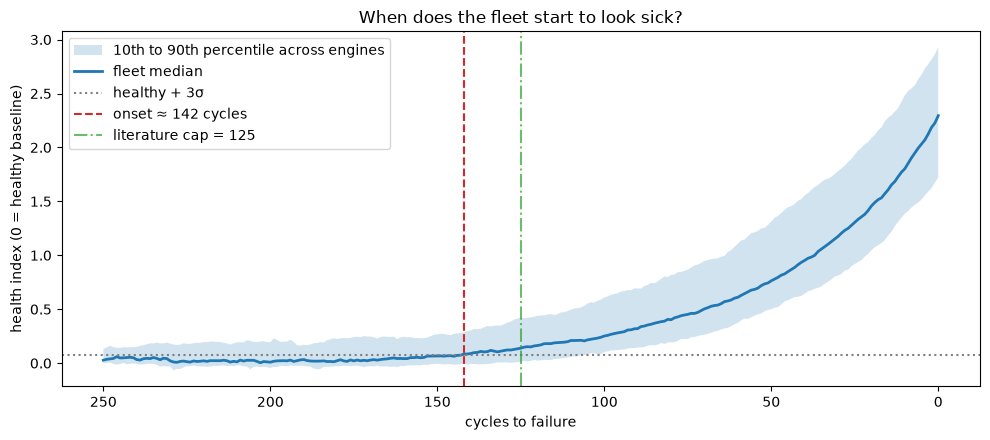

In [14]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(fleet.index, fleet[0.1], fleet[0.9], alpha=0.2, label="10th to 90th percentile across engines")
ax.plot(fleet.index, fleet[0.5], lw=2, label="fleet median")
ax.axhline(threshold, color="grey", ls=":", label="healthy + 3σ")
ax.axvline(onset, color="C3", ls="--", label=f"onset ≈ {onset} cycles")
ax.axvline(125, color="C2", ls="-.", alpha=0.7, label="literature cap = 125")
ax.invert_xaxis()
ax.set(xlabel="cycles to failure", ylabel="health index (0 = healthy baseline)",
       title="When does the fleet start to look sick?")
ax.legend()
plt.tight_layout()
plt.show()

There is no sharp knee. The fleet median leaves the healthy band gradually and then accelerates, so "onset" depends on the threshold, and the honest thing to report is a band rather than a single number. Two ways to be stricter: a higher sigma multiple, or requiring the 10th percentile (the slowest-degrading engines) to clear the threshold instead of just the median.

In [15]:
rows = []
for k in (2, 3, 5):
    thr = healthy.mean() + k * healthy.std()
    rows.append({"threshold": f"healthy + {k}σ",
                 "median crosses at": fleet.index[fleet[0.5] > thr].max(),
                 "10th pct crosses at": fleet.index[fleet[0.1] > thr].max()})
pd.DataFrame(rows).set_index("threshold")

,median crosses at,10th pct crosses at
threshold,,
healthy + 2σ,153,109
healthy + 3σ,142,107
healthy + 5σ,137,99


Depending on how strict you are, detectable degradation starts somewhere between 100 and 140 cycles before failure. The cap of 125 used in the literature sits inside that band, which is probably why it became the convention. We adopt `RUL_CAP = 125` from `config.py`, noting that anything from 100 to 140 is defensible. How sensitive the final model is to this choice is worth one experiment later.

Now build both labels and look at them next to the health index for one engine.

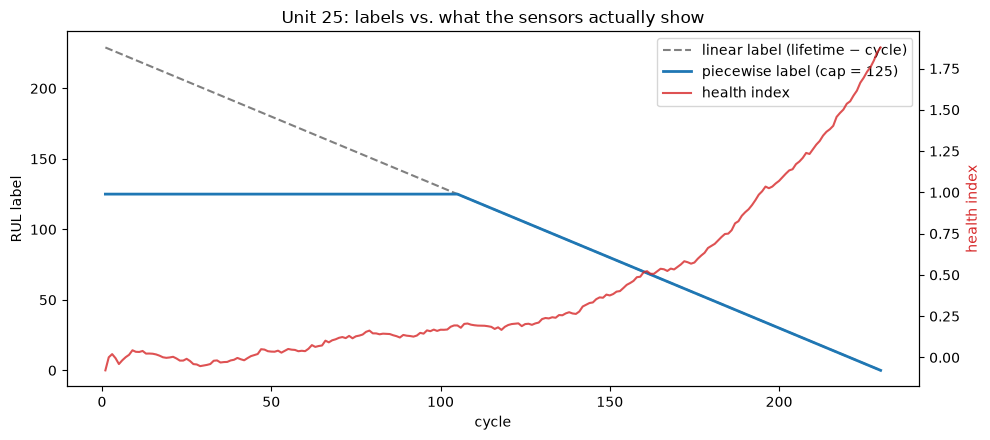

In [16]:
from turbofan_rul.config import RUL_CAP
from turbofan_rul.data_loading import add_rul_labels

df = add_rul_labels(df, cap=None).rename(columns={"rul": "rul_linear"})
df = add_rul_labels(df, cap=RUL_CAP)

u = df[df["unit"] == 25]
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(u["cycle"], u["rul_linear"], color="grey", ls="--", label="linear label (lifetime − cycle)")
ax1.plot(u["cycle"], u["rul"], color="C0", lw=2, label=f"piecewise label (cap = {RUL_CAP})")
ax1.set(xlabel="cycle", ylabel="RUL label", title="Unit 25: labels vs. what the sensors actually show")
ax2 = ax1.twinx()
ax2.plot(u["cycle"], u["health_index"], color="C3", alpha=0.8, label="health index")
ax2.set_ylabel("health index", color="C3")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
plt.tight_layout()
plt.show()

The grey line asks the model to tell "RUL = 280" from "RUL = 200" while the red line is flat: nothing in the sensors separates those two rows. The blue label stops asking that. It also changes what "error" means: a model that predicts 125 for every healthy row is right, and the training signal concentrates where the sensors carry information.

One side effect to remember: with the cap, the label distribution has a spike at 125. Any metric averaged over all rows is dominated by the easy healthy rows, so evaluation should focus on the degradation phase (and, officially, on one prediction per test engine at its cutoff).

---

## Decisions

| # | Question | Decision | Evidence |
|---|----------|----------|----------|
| 1 | RUL label | Piecewise linear, cap = 125 | Fleet health index leaves the healthy band 100 to 140 cycles before failure (section 4) |
| 2 | Sensors | Raw: 2, 3, 4, 7, 8, 11, 12, 13, 15, 17, 20, 21. As deviation from own baseline: 9, 14. Drop: 1, 5, 6, 10, 16, 18, 19 | Constant, no drift, or bimodal sign (section 3) |
| 3 | Lifetimes | 128 to 362 cycles, right-skewed. Sensors are needed; a clock model is off by about 46 cycles on average | section 2 |
| 4 | Validation | Split by engine, never by row. Stratify, or at least check that long-lived engines appear on both sides | Row-level correlation and engine-specific baselines (section 3a, readme) |
| 5 | Settings | Ignore in FD001 (single regime, sea level) | std close to 0, no structure (section 2) |

Notes to carry into the next notebooks:

- Sensors 8 and 13 are the noisiest survivors and candidates for longer smoothing windows.
- Deviation from the engine's own early-life baseline removed the engine offset for 9 and 14. Test it as a feature for all sensors, not just those two.
- Both the baseline (first 20 cycles) and any rolling window assume every engine is observed from cycle 1. That holds in train and test here but is not guaranteed in a real fleet.
- The sensor list and the cap are specific to FD001. Re-run sections 3 and 4 before reusing them on FD002 to FD004.